In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/navneet0094/kdef-dataset/KDEF_and_AKDEF/References.txt
/kaggle/input/datasets/navneet0094/kdef-dataset/KDEF_and_AKDEF/ReadThis.TXT
/kaggle/input/datasets/navneet0094/kdef-dataset/KDEF_and_AKDEF/ReadThis/AKDEF.DOC
/kaggle/input/datasets/navneet0094/kdef-dataset/KDEF_and_AKDEF/ReadThis/KDEF.DOC
/kaggle/input/datasets/navneet0094/kdef-dataset/KDEF_and_AKDEF/ReadThis/ReadThis.rtf
/kaggle/input/datasets/navneet0094/kdef-dataset/KDEF_and_AKDEF/KDEF/BF19/BF19ANHR.JPG
/kaggle/input/datasets/navneet0094/kdef-dataset/KDEF_and_AKDEF/KDEF/BF19/BF19DIFL.JPG
/kaggle/input/datasets/navneet0094/kdef-dataset/KDEF_and_AKDEF/KDEF/BF19/BF19AFHR.JPG
/kaggle/input/datasets/navneet0094/kdef-dataset/KDEF_and_AKDEF/KDEF/BF19/BF19SUFR.JPG
/kaggle/input/datasets/navneet0094/kdef-dataset/KDEF_and_AKDEF/KDEF/BF19/BF19HAFR.JPG
/kaggle/input/datasets/navneet0094/kdef-dataset/KDEF_and_AKDEF/KDEF/BF19/BF19NES.JPG
/kaggle/input/datasets/navneet0094/kdef-dataset/KDEF_and_AKDEF/KDEF/BF19/BF19DIHR.J

In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import os
import cv2
import numpy as np

data = []
labels = []

emotion_map = {
    'AN':0,   # Angry
    'DI':1,   # Disgust
    'AF':2,   # Fear
    'HA':3,   # Happy
    'SA':4,   # Sad
    'SU':5,   # Surprise
    'NE':6    # Neutral
}

emotion_names = [
    'Angry',
    'Disgust',
    'Fear',
    'Happy',
    'Sad',
    'Surprise',
    'Neutral'
]

kdef_path = "/kaggle/input/datasets/navneet0094/kdef-dataset/KDEF_and_AKDEF/KDEF"

# subject folders
for folder in os.listdir(kdef_path):

    folder_path = os.path.join(kdef_path, folder)

    if not os.path.isdir(folder_path):
        continue

    # images inside each subject folder
    for img_name in os.listdir(folder_path):

        if not img_name.endswith(".JPG"):
            continue

        try:

            # emotion code from filename
            # example: AF01ANFL.JPG
            emotion_code = img_name[4:6]

            if emotion_code not in emotion_map:
                continue

            img_path = os.path.join(folder_path, img_name)

            # grayscale
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is None:
                continue

            # resize
            img = cv2.resize(img, (48,48))

            data.append(img)

            labels.append(emotion_map[emotion_code])

        except Exception as e:
            print("Error:", img_name)

data = np.array(data)
labels = np.array(labels)

print("Data shape:", data.shape)
print("Labels:", np.unique(labels))

Data shape: (4898, 48, 48)
Labels: [0 1 2 3 4 5 6]


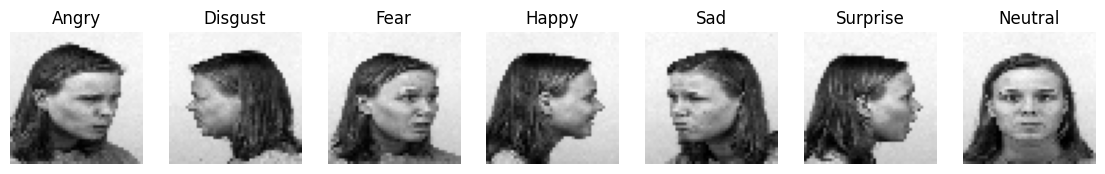

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

for i in range(7):

    idx = np.where(labels == i)[0][0]

    plt.subplot(1,7,i+1)

    plt.imshow(data[idx], cmap='gray')

    plt.title(emotion_names[i])

    plt.axis('off')

plt.show()

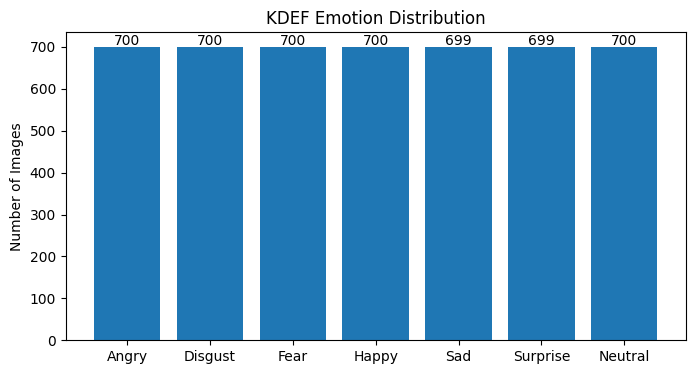

In [6]:
unique, counts = np.unique(labels, return_counts=True)

plt.figure(figsize=(8,4))

bars = plt.bar(emotion_names, counts)

plt.title("KDEF Emotion Distribution")

plt.ylabel("Number of Images")

for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        yval+5,
        str(yval),
        ha='center'
    )

plt.show()

In [7]:
from sklearn.model_selection import train_test_split

X_train_img, X_test_img, y_train, y_test = train_test_split(
    data,
    labels,
    test_size=0.3,
    random_state=42,
    stratify=labels
)

print("Train:", X_train_img.shape)
print("Test:", X_test_img.shape)

Train: (3428, 48, 48)
Test: (1470, 48, 48)


In [8]:
from skimage.feature import hog

def extract_hog(images):

    hog_features = []

    for img in images:

        features = hog(
            img,
            orientations=9,
            pixels_per_cell=(8,8),
            cells_per_block=(2,2)
        )

        hog_features.append(features)

    return np.array(hog_features)

In [9]:
X_train_hog = extract_hog(X_train_img)

X_test_hog = extract_hog(X_test_img)

print("Train HOG:", X_train_hog.shape)
print("Test HOG:", X_test_hog.shape)

Train HOG: (3428, 900)
Test HOG: (1470, 900)


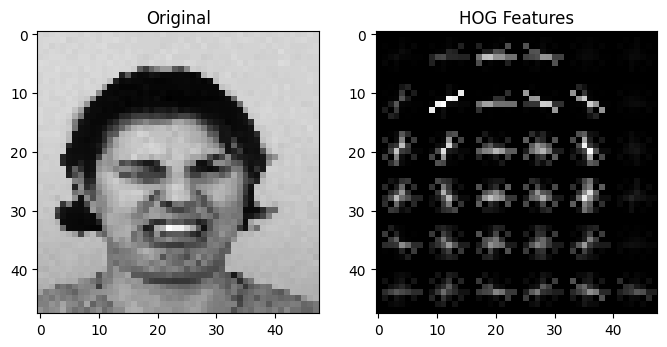

In [10]:
sample_img = X_train_img[0]

features, hog_image = hog(
    sample_img,
    orientations=9,
    pixels_per_cell=(8,8),
    cells_per_block=(2,2),
    visualize=True
)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(sample_img, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(hog_image, cmap='gray')
plt.title("HOG Features")

plt.show()

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_hog = scaler.fit_transform(X_train_hog)

X_test_hog = scaler.transform(X_test_hog)

In [12]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

hog_model = LinearSVC()

hog_model.fit(X_train_hog, y_train)

y_pred_hog = hog_model.predict(X_test_hog)

acc_hog = accuracy_score(y_test, y_pred_hog)

print("KDEF HOG Accuracy:", acc_hog)

KDEF HOG Accuracy: 0.3163265306122449


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [13]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_hog,
    target_names=emotion_names
))

              precision    recall  f1-score   support

       Angry       0.42      0.48      0.45       210
     Disgust       0.30      0.28      0.29       210
        Fear       0.23      0.22      0.22       210
       Happy       0.39      0.40      0.40       210
         Sad       0.18      0.16      0.17       210
    Surprise       0.36      0.39      0.37       210
     Neutral       0.30      0.28      0.29       210

    accuracy                           0.32      1470
   macro avg       0.31      0.32      0.31      1470
weighted avg       0.31      0.32      0.31      1470



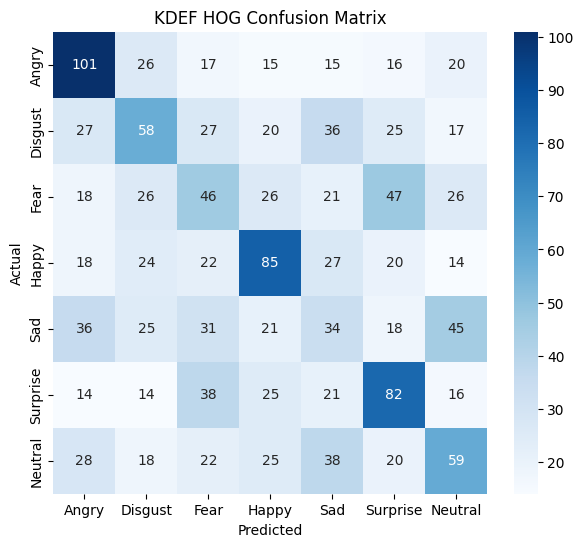

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_hog)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=emotion_names,
    yticklabels=emotion_names
)

plt.title("KDEF HOG Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [15]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', LinearSVC())
])

# HOG features from ALL images
X_hog_all = extract_hog(data)

cv_hog = cross_val_score(
    pipeline,
    X_hog_all,
    labels,
    cv=skf,
    n_jobs=-1
)

print("HOG CV Scores:", cv_hog)

print("Mean:", cv_hog.mean())

print("Std:", cv_hog.std())

HOG CV Scores: [0.33061224 0.34489796 0.30612245 0.34320735 0.3258427 ]
Mean: 0.3301365408267495
Std: 0.014029152790577103


In [16]:
from sklearn.model_selection import KFold

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [17]:
cv_hog = cross_val_score(
    pipeline,
    X_hog_all,
    labels,
    cv=kf,
    n_jobs=-1
)

In [18]:
import tensorflow as tf

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications import VGG16

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess

# MobileNetV2
mobilenet = MobileNetV2(
    weights='imagenet',
    include_top=False,
    pooling='avg'
)

# VGG16
vgg = VGG16(
    weights='imagenet',
    include_top=False,
    pooling='avg'
)

print("Models Loaded")

2026-05-08 16:46:19.620157: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778258779.871501      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778258779.932298      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778258780.497349      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778258780.497378      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778258780.497381      57 computation_placer.cc:177] computation placer alr

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Models Loaded


In [19]:
def extract_mobilenet_features(images, model):

    features = []

    for img in images:

        # resize
        img = cv2.resize(img, (224,224))

        # grayscale → RGB
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

        # preprocessing
        img = preprocess_input(img)

        # batch dimension
        img = np.expand_dims(img, axis=0)

        # feature extraction
        feat = model.predict(img, verbose=0)

        features.append(feat.flatten())

    return np.array(features)

In [20]:
def extract_vgg_features(images, model):

    features = []

    for img in images:

        img = cv2.resize(img, (224,224))

        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

        img = vgg_preprocess(img)

        img = np.expand_dims(img, axis=0)

        feat = model.predict(img, verbose=0)

        features.append(feat.flatten())

    return np.array(features)

In [21]:
X_train_cnn = extract_mobilenet_features(
    X_train_img,
    mobilenet
)

X_test_cnn = extract_mobilenet_features(
    X_test_img,
    mobilenet
)

print("MobileNet Train:", X_train_cnn.shape)
print("MobileNet Test:", X_test_cnn.shape)

I0000 00:00:1778258812.405838     155 service.cc:152] XLA service 0x7bdd1403dfc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778258812.405886     155 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778258812.405894     155 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778258813.060048     155 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-08 16:47:01.711822: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-08 16:47:01.846462: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1778258823.223432     155 device_co

MobileNet Train: (3428, 1280)
MobileNet Test: (1470, 1280)


In [22]:
X_train_vgg = extract_vgg_features(
    X_train_img,
    vgg
)

X_test_vgg = extract_vgg_features(
    X_test_img,
    vgg
)

print("VGG Train:", X_train_vgg.shape)
print("VGG Test:", X_test_vgg.shape)

VGG Train: (3428, 512)
VGG Test: (1470, 512)


In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

scaler = StandardScaler()

X_train_cnn_scaled = scaler.fit_transform(X_train_cnn)

X_test_cnn_scaled = scaler.transform(X_test_cnn)

cnn_model = LinearSVC()

cnn_model.fit(X_train_cnn_scaled, y_train)

y_pred_cnn = cnn_model.predict(X_test_cnn_scaled)

acc_cnn = accuracy_score(y_test, y_pred_cnn)

print("MobileNet Accuracy:", acc_cnn)

MobileNet Accuracy: 0.354421768707483


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [24]:
scaler = StandardScaler()

X_train_vgg_scaled = scaler.fit_transform(X_train_vgg)

X_test_vgg_scaled = scaler.transform(X_test_vgg)

vgg_model = LinearSVC()

vgg_model.fit(X_train_vgg_scaled, y_train)

y_pred_vgg = vgg_model.predict(X_test_vgg_scaled)

acc_vgg = accuracy_score(y_test, y_pred_vgg)

print("VGG Accuracy:", acc_vgg)

VGG Accuracy: 0.42448979591836733


In [25]:
X_train_hybrid = np.concatenate(
    [X_train_cnn, X_train_vgg],
    axis=1
)

X_test_hybrid = np.concatenate(
    [X_test_cnn, X_test_vgg],
    axis=1
)

print(X_train_hybrid.shape)

(3428, 1792)


In [26]:
X_train_hog_cnn = np.concatenate(
    [X_train_hog, X_train_cnn],
    axis=1
)

X_test_hog_cnn = np.concatenate(
    [X_test_hog, X_test_cnn],
    axis=1
)

In [27]:
X_train_final = np.concatenate(
    [X_train_hog, X_train_hybrid],
    axis=1
)

X_test_final = np.concatenate(
    [X_test_hog, X_test_hybrid],
    axis=1
)

In [28]:
def evaluate_model(
    X_train,
    X_test,
    y_train,
    y_test,
    name
):

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)

    X_test = scaler.transform(X_test)

    model = LinearSVC(max_iter=10000)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print(f"{name} Accuracy:", acc)

    return acc

In [29]:
acc_hog = evaluate_model(
    X_train_hog,
    X_test_hog,
    y_train,
    y_test,
    "HOG"
)

acc_cnn = evaluate_model(
    X_train_cnn,
    X_test_cnn,
    y_train,
    y_test,
    "MobileNet"
)

acc_vgg = evaluate_model(
    X_train_vgg,
    X_test_vgg,
    y_train,
    y_test,
    "VGG"
)

acc_hybrid = evaluate_model(
    X_train_hybrid,
    X_test_hybrid,
    y_train,
    y_test,
    "Hybrid CNN"
)




HOG Accuracy: 0.3142857142857143
MobileNet Accuracy: 0.35374149659863946
VGG Accuracy: 0.42448979591836733
Hybrid CNN Accuracy: 0.43537414965986393


In [30]:
X_train_hog_vgg = np.concatenate(
    [X_train_hog, X_train_vgg],
    axis=1
)

X_test_hog_vgg = np.concatenate(
    [X_test_hog, X_test_vgg],
    axis=1
)

print(X_train_hog_vgg.shape)
print(X_test_hog_vgg.shape)

(3428, 1412)
(1470, 1412)


In [31]:
X_train_final = np.concatenate(
    [X_train_hog, X_train_hybrid],
    axis=1
)

X_test_final = np.concatenate(
    [X_test_hog, X_test_hybrid],
    axis=1
)

In [32]:
acc_hog_vgg = evaluate_model(
    X_train_hog_vgg,
    X_test_hog_vgg,
    y_train,
    y_test,
    "HOG + VGG"
)



HOG + VGG Accuracy: 0.41768707482993195


In [ ]:
acc_final = evaluate_model(
    X_train_final,
    X_test_final,
    y_train,
    y_test,
    "HOG + Hybrid"
)

In [ ]:
models = [
    'HOG',
    'MobileNet',
    'VGG',
    'Hybrid',
    'HOG+MobileNet',
    'HOG+VGG',
    'HOG+Hybrid'
]

scores = [
    acc_hog,
    acc_cnn,
    acc_vgg,
    acc_hybrid,
    acc_hog_cnn,
    acc_hog_vgg,
    acc_final
]

plt.figure(figsize=(10,5))

bars = plt.bar(models, scores)

plt.ylim(0,1)

plt.title("KDEF Model Comparison")

plt.ylabel("Accuracy")

for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        yval+0.01,
        f"{yval:.2f}",
        ha='center'
    )

plt.xticks(rotation=20)

plt.show()

In [ ]:
cv_hog_hybrid = cross_val_score(
    pipeline,
    X_final_all,
    labels_all,
    cv=5
)

In [ ]:
cv_hog_vgg = cross_val_score(
    pipeline,
    X_train_hog_vgg,
    np.concatenate([y_train, y_test]),
    cv=5
)

In [ ]:
cv_hog_hybrid = cross_val_score(
    pipeline,
    X_final_all,
    labels_all,
    cv=5
)

In [ ]:
print("HOG+Hybrid CV Mean:", cv_hog_hybrid.mean(),
      "Std:", cv_hog_hybrid.std())

print("Hybrid CV Mean:", cv_hybrid.mean(),
      "Std:", cv_hybrid.std())

print("HOG+VGG CV Mean:", cv_hog_vgg.mean(),
      "Std:", cv_hog_vgg.std())

In [ ]:
models = ['HOG+Hybrid', 'Hybrid', 'HOG+VGG']

means = [
    cv_hog_hybrid.mean(),
    cv_hybrid.mean(),
    cv_hog_vgg.mean()
]

plt.figure(figsize=(7,4))

bars = plt.bar(models, means)

plt.ylim(0,1)

plt.title("5-Fold CV Comparison (Top Models)")

plt.ylabel("Accuracy")

for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        yval+0.02,
        f"{yval:.2f}",
        ha='center'
    )

plt.show()